# Use your own data

This example builds a dataset from two coordinate arrays and one field array,
which is the form most simulation output and most gridded measurements already
have. The other examples start from a dataset shipped with KD.

The field below is generated with NumPy to give the example concrete data.
Substituting your own arrays requires no other change.


## Build the dataset

`kd.PDEDataset.from_arrays` needs three things: one 1-D array per coordinate
axis, one field array shaped to those axes in order, and the name of the term
that goes on the left-hand side. The full contract is under
[Data requirements](../../data/shape/).


In [1]:
import numpy as np

import kd

k = 0.1
x = np.linspace(0.0, 1.0, 128)
t = np.linspace(0.0, 0.5, 101)
X, T = np.meshgrid(x, t, indexing="ij")
u = np.exp(-(np.pi**2) * k * T) * np.sin(np.pi * X) + 0.5 * np.exp(
    -4 * (np.pi**2) * k * T
) * np.sin(2 * np.pi * X)

dataset = kd.PDEDataset.from_arrays(
    coords={"x": x, "t": t},
    fields={"u": u},
    lhs="u_t",
    name="my-data",
)
kd.preview(dataset)

Dataset: my-data
Axes:
     x | n=128  | range [0.000, 1.000] | step 0.007874 (uniform)
     t | n=101  | range [0.000, 0.500] | step 0.005 (uniform)
Fields:
     u | dtype=float64 | shape=(128, 101) | min=0.000 max=1.299 mean=0.499 (NaN=0)
LHS: u_t  (field='u', axis='t')
Status: ready to fit


`kd.preview` reports what KD read: the axes and their spacing, the field and
its range, and the left-hand side it will fit. `Status: ready to fit` means
the dataset satisfies the contract.


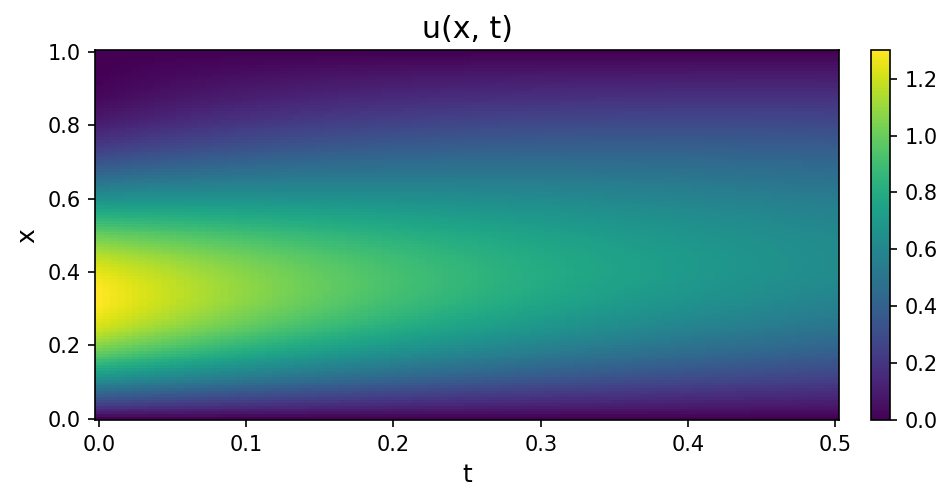

In [2]:
kd.viz.plots.plot_field(dataset)

## Fit an algorithm

Fitting is a single call. `seed` makes the run reproducible, and `generations`
sets the search budget.


In [3]:
model = kd.Model(algorithm="sga", generations=20, seed=2, verbose=False).fit(dataset)
model

Model(algorithm='sga', fitted=True, best_expr='u_t = 0.09998*u_xx', best_score=-24.38)

The displayed second derivative `u_xx` identifies the heat equation the field
was built from. Raw term exports spell it `diff2_x(u)`; the same IR vocabulary
is used by every algorithm and is described under
[Equation representation](../../design/ir/).

The displayed score is SGA-PDE AIC; lower values indicate a better fit under
that criterion.


## Render the report

`model.report` writes every figure that applies to this fit, plus one HTML
page collecting them. The report is displayed inline below.


In [4]:
model.report("../out/my_data")

ReportResult(figures=[PosixPath('../out/my_data/convergence.svg'), PosixPath('../out/my_data/parity.svg'), PosixPath('../out/my_data/equation.svg'), PosixPath('../out/my_data/equation_tree.svg'), PosixPath('../out/my_data/residual.svg'), PosixPath('../out/my_data/coefficient_bar.svg'), PosixPath('../out/my_data/field_comparison.svg'), PosixPath('../out/my_data/pde_residual_field.svg'), PosixPath('../out/my_data/time_slices.svg'), PosixPath('../out/my_data/error_heatmap.svg'), PosixPath('../out/my_data/plugin_population_diversity.svg'), PosixPath('../out/my_data/plugin_complexity_evolution.svg'), PosixPath('../out/my_data/plugin_fitness_spread.svg'), PosixPath('../out/my_data/plugin_surrogate_training.svg'), PosixPath('../out/my_data/plugin_genome_tree.svg')], data_files=[], report=PosixPath('../out/my_data/report.html'), warnings=["plugin plot 'surrogate_training': No data (no surrogate training logged for this run)"])

## Measured data

The derivatives above came from finite differences on the grid, which suits
clean simulation output. For measured data, pass `derivatives="autograd"` to
`kd.Model`: KD then fits a smooth surrogate to the field and differentiates
that, which handles noise and points that are not evenly spaced. The two
routes are compared under [Derivative sources](../../data/derivatives/).


## Next steps

- [Getting started](../getting_started/) -- the same workflow on a bundled
  benchmark, with more of the result surface explained.
- [Breaking waves](../wave_breaking/) -- a published result reproduced on real
  wave-tank measurements.
- [Algorithms](../../algorithms/) -- what each of the seven searches, and a
  worked example for each.
